In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BUSINESS CASE : 

# DOMAIN ANALYSIS :

# BASIC CHECKS

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [5]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [6]:
df.head(2)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55


In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

# EDA

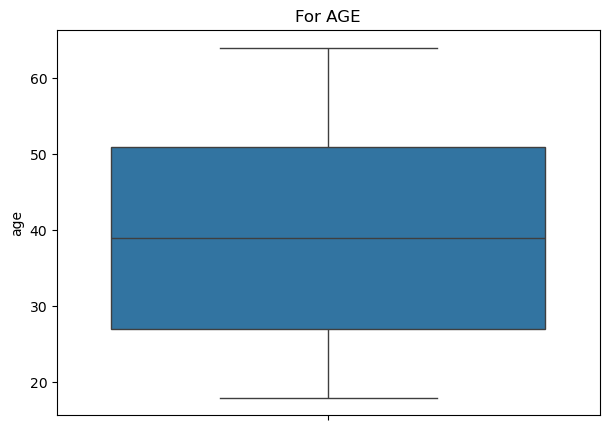

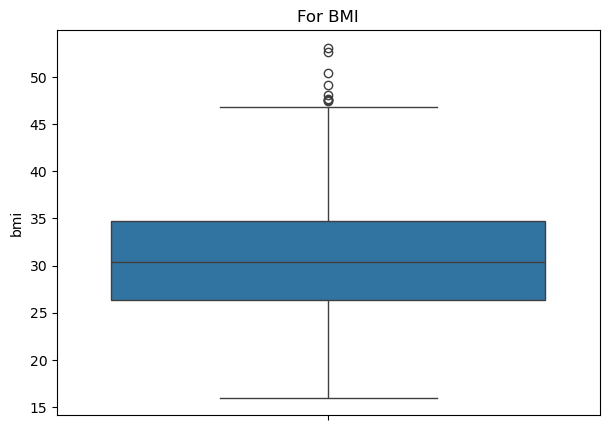

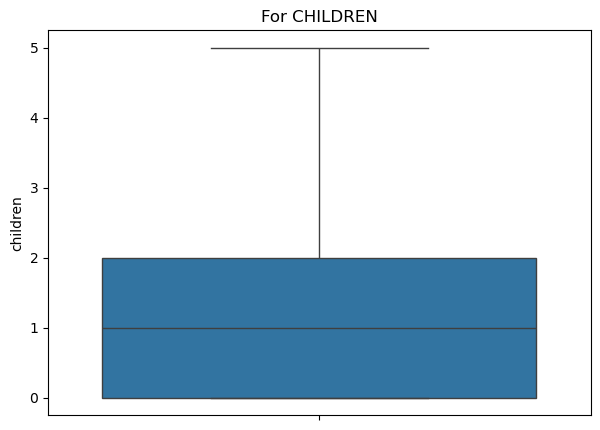

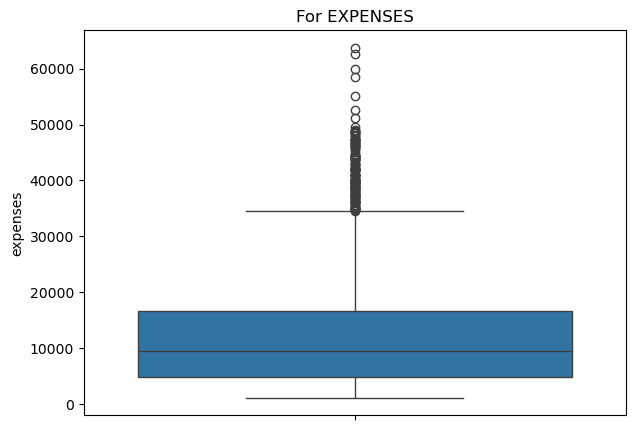

In [9]:
num_cols = ['age', 'bmi', 'children', 'expenses']

for col in num_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(df[col])
    plt.title(f"For {col.upper()}")
    plt.show()

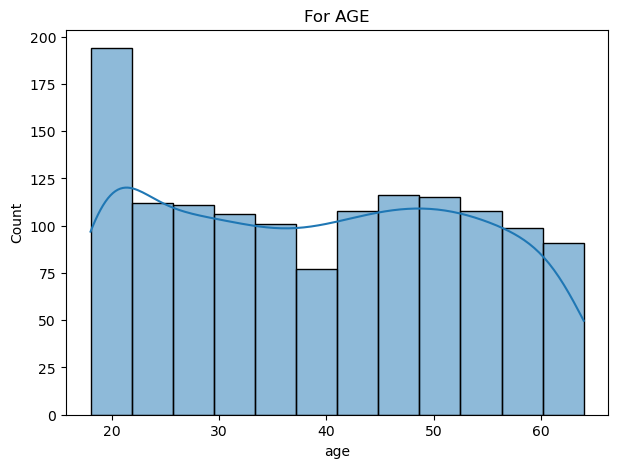

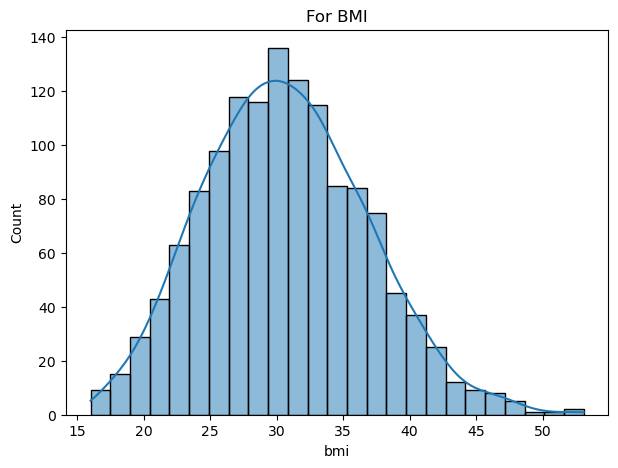

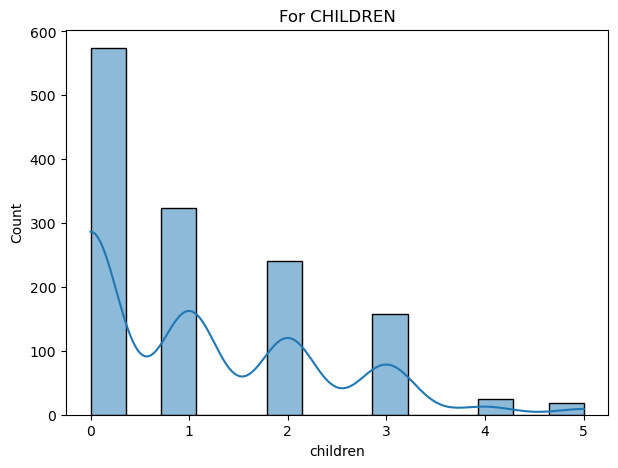

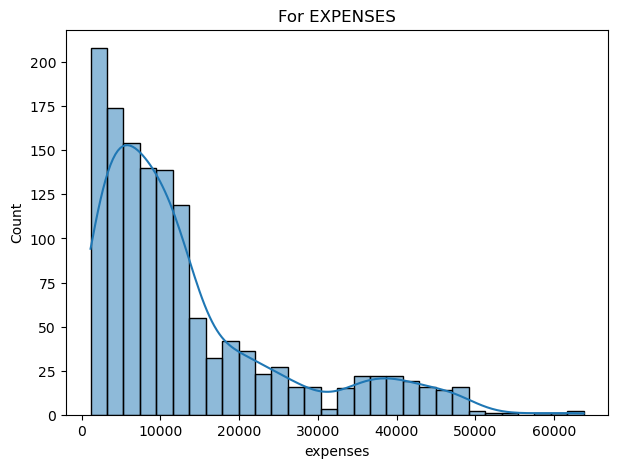

In [10]:
for col in num_cols:
    plt.figure(figsize=(7,5))
    sns.histplot(df[col], kde = True)
    plt.title(f"For {col.upper()}")
    plt.show()

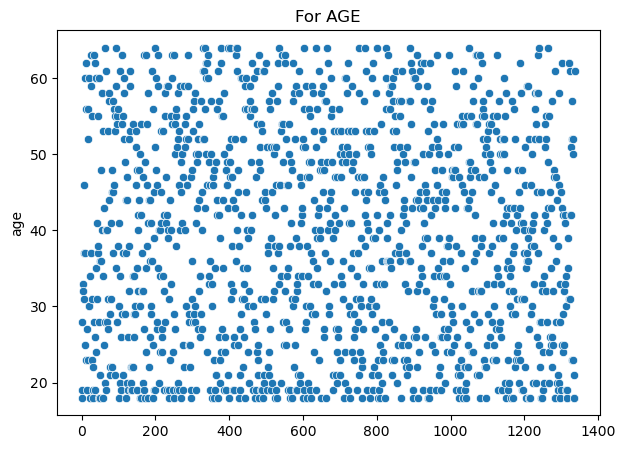

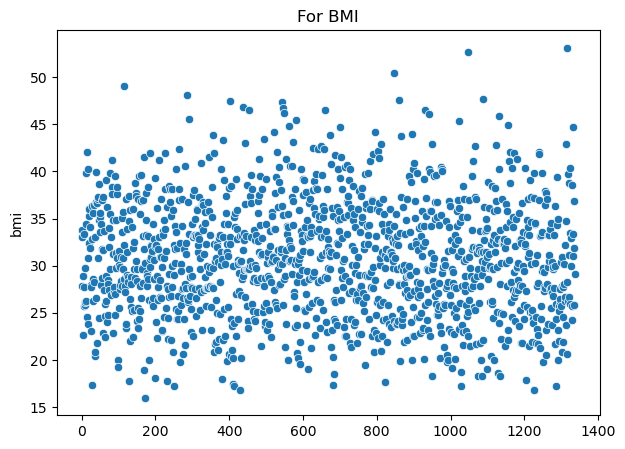

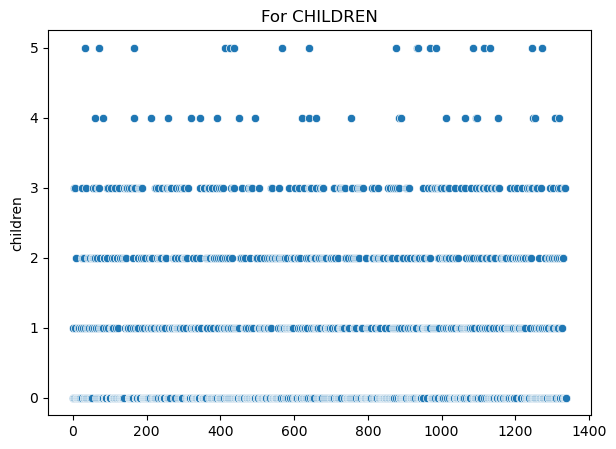

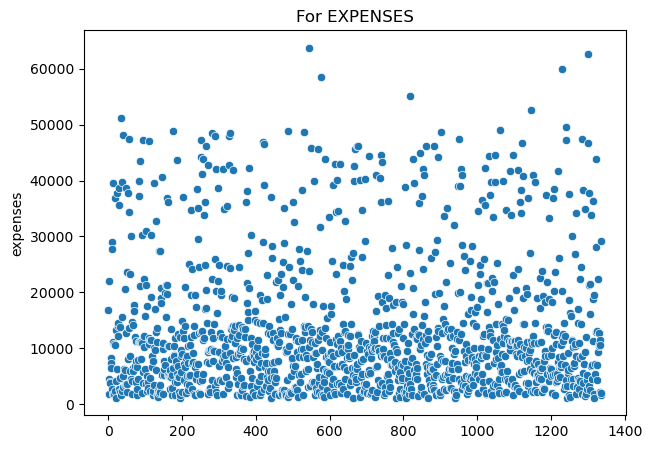

In [11]:
for col in num_cols:
    plt.figure(figsize=(7,5))
    sns.scatterplot(df[col])
    plt.title(f"For {col.upper()}")
    plt.show()

In [12]:
# no relation

# Handling outliers

In [13]:
def handle_outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    low = q1-1.5*iqr
    high = q3+1.5*iqr
    return low, high

In [14]:
num_cols = ['bmi', 'expenses']

In [15]:
for col in num_cols:
    low,high = handle_outliers(col)

    df.loc[df[col] < low , col] = low
    df.loc[df[col] > high, col] = high

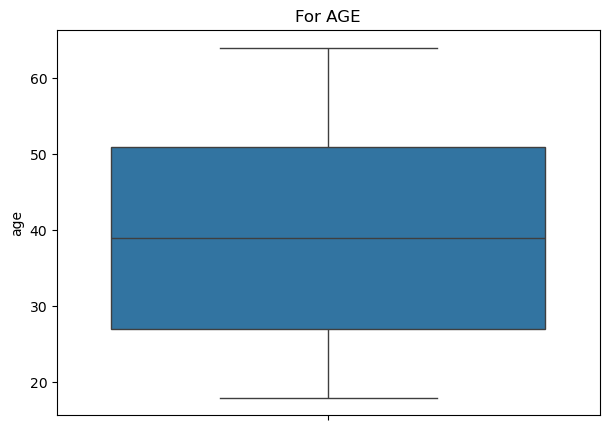

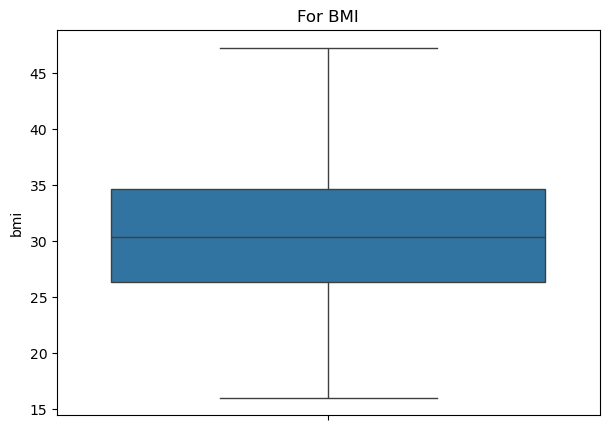

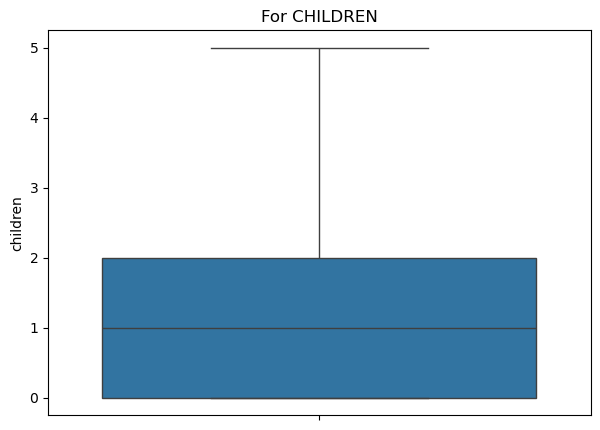

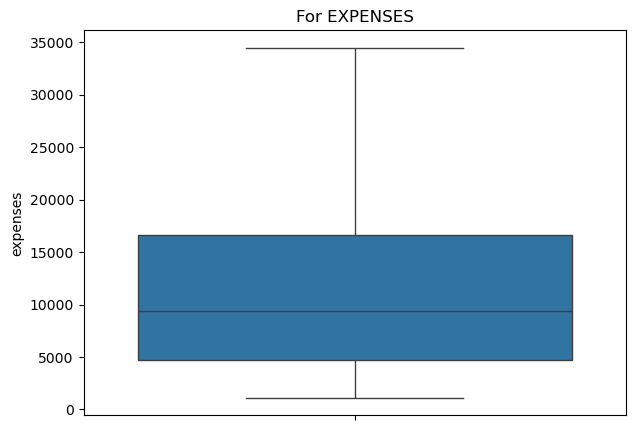

In [16]:
num_cols = ['age', 'bmi', 'children', 'expenses']

for col in num_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(df[col])
    plt.title(f"For {col.upper()}")
    plt.show()

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [18]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [19]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [20]:
cat_cols = df.select_dtypes(include = 'O').columns
for col in cat_cols:
    print(f"===Value Counts for {col.upper()}===")
    print(df[col].value_counts())
    print("-"*35)

===Value Counts for SEX===
sex
male      676
female    662
Name: count, dtype: int64
-----------------------------------
===Value Counts for SMOKER===
smoker
no     1064
yes     274
Name: count, dtype: int64
-----------------------------------
===Value Counts for REGION===
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
-----------------------------------


C:\Users\BansariGoswami\AppData\Local\Temp\ipykernel_9324\1079923940.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include = 'O').columns


# Performing manual encoding for categorical columns

In [21]:
df = pd.get_dummies(df , drop_first=True , dtype=int)
df.head(10)

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,0,1,0,0,1
1,18,33.8,1,1725.55,1,0,0,1,0
2,28,33.0,3,4449.46,1,0,0,1,0
3,33,22.7,0,21984.47,1,0,1,0,0
4,32,28.9,0,3866.86,1,0,1,0,0
5,31,25.7,0,3756.62,0,0,0,1,0
6,46,33.4,1,8240.59,0,0,0,1,0
7,37,27.7,3,7281.51,0,0,1,0,0
8,37,29.8,2,6406.41,1,0,0,0,0
9,60,25.8,0,28923.14,0,0,1,0,0


In [22]:
df

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,0,1,0,0,1
1,18,33.8,1,1725.55,1,0,0,1,0
2,28,33.0,3,4449.46,1,0,0,1,0
3,33,22.7,0,21984.47,1,0,1,0,0
4,32,28.9,0,3866.86,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,31.0,3,10600.55,1,0,1,0,0
1334,18,31.9,0,2205.98,0,0,0,0,0
1335,18,36.9,0,1629.83,0,0,0,1,0
1336,21,25.8,0,2007.95,0,0,0,0,1


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   expenses          1338 non-null   float64
 4   sex_male          1338 non-null   int64  
 5   smoker_yes        1338 non-null   int64  
 6   region_northwest  1338 non-null   int64  
 7   region_southeast  1338 non-null   int64  
 8   region_southwest  1338 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 94.2 KB


# MODEL SELECTION

In [24]:
X = df.drop('expenses',axis = 1)
y = df.expenses

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

# MODEL CREATION, TRAINING AND EVALUATION

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [28]:
lr = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()
gb = GradientBoostingRegressor()
xgb = XGBRegressor()

# CHECKING THAT MODEL IS GENERALIZED OR NOT?

In [29]:
print("FOR LINEAR/ REGRESSION : ")
lr.fit(x_train,y_train)
y_pred_lr = lr.predict(x_test)
print('r2_score : ' , r2_score(y_test,y_pred_lr))
print('mean_absolute_error : ' , mean_absolute_error(y_test,y_pred_lr))
print('root_mean_squared_error : ' , root_mean_squared_error(y_test,y_pred_lr))
print('mean_squared_error : ' , mean_squared_error(y_test,y_pred_lr))
print('-'*20)

FOR LINEAR/ REGRESSION : 
r2_score :  0.7840811233559495
mean_absolute_error :  3316.4719703346814
root_mean_squared_error :  4841.4261076706825
mean_squared_error :  23439406.756035294
--------------------


In [30]:
y_pred_lr_train = lr.predict(x_train)
print('r2_score : ' , r2_score(y_train,y_pred_lr_train))
print('mean_absolute_error : ' , mean_absolute_error(y_train,y_pred_lr_train))
print('root_mean_squared_error : ' , root_mean_squared_error(y_train,y_pred_lr_train))
print('mean_squared_error : ' , mean_squared_error(y_train,y_pred_lr_train))
print('-'*40)

r2_score :  0.737638602226047
mean_absolute_error :  3394.579500044916
root_mean_squared_error :  5165.638616781
mean_squared_error :  26683822.31917912
----------------------------------------


#### **Here Linear Regression model can be said as *generalized* model after getting r2 score and mean absolute error**

In [31]:
print("FOR DECISION TREE REGRESSOR : ")
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print('r2_score : ' , r2_score(y_test,y_pred_dt))
print('mean_absolute_error : ' , mean_absolute_error(y_test,y_pred_dt))
print('root_mean_squared_error : ' , root_mean_squared_error(y_test,y_pred_dt))
print('mean_squared_error : ' , mean_squared_error(y_test,y_pred_dt))
print('-'*20)

FOR DECISION TREE REGRESSOR : 
r2_score :  0.7106799766342903
mean_absolute_error :  2494.213236940301
root_mean_squared_error :  5604.246735795654
mean_squared_error :  31407581.475676246
--------------------


In [32]:
y_pred_dt_train = dt.predict(x_train)
print('r2_score : ' , r2_score(y_train,y_pred_dt_train))
print('mean_absolute_error : ' , mean_absolute_error(y_train,y_pred_dt_train))
print('root_mean_squared_error : ' , root_mean_squared_error(y_train,y_pred_dt_train))
print('mean_squared_error : ' , mean_squared_error(y_train,y_pred_dt_train))
print('-'*40)

r2_score :  0.997598579961325
mean_absolute_error :  29.572523364488323
root_mean_squared_error :  494.2061177475097
mean_squared_error :  244239.68681906545
----------------------------------------


#### **Here Decision Tree model can be said as *overfitted* model after getting r2 score and mean absolute error**

In [33]:
print("FOR RANDOM FOREST REGRESSOR : ")
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print('r2_score : ' , r2_score(y_test,y_pred_rf))
print('mean_absolute_error : ' , mean_absolute_error(y_test,y_pred_rf))
print('root_mean_squared_error : ' , root_mean_squared_error(y_test,y_pred_rf))
print('mean_squared_error : ' , mean_squared_error(y_test,y_pred_rf))
print('-'*20)

FOR RANDOM FOREST REGRESSOR : 
r2_score :  0.8281111647396349
mean_absolute_error :  2270.9763940951525
root_mean_squared_error :  4319.682591081359
mean_squared_error :  18659657.68769136
--------------------


In [34]:
y_pred_rf_train = rf.predict(x_train)
print('r2_score : ' , r2_score(y_train,y_pred_rf_train))
print('mean_absolute_error : ' , mean_absolute_error(y_train,y_pred_rf_train))
print('root_mean_squared_error : ' , root_mean_squared_error(y_train,y_pred_rf_train))
print('mean_squared_error : ' , mean_squared_error(y_train,y_pred_rf_train))
print('-'*40)

r2_score :  0.9681440721121636
mean_absolute_error :  969.0803160545198
root_mean_squared_error :  1799.9862263085695
mean_squared_error :  3239950.414900565
----------------------------------------


#### **Here Random Forest model can be said as *overfitted* model after getting r2 score and mean absolute error**

In [35]:
print("FOR GRADIENT BOOSTING REGRESSOR : ")
gb.fit(x_train,y_train)
y_pred_gb = gb.predict(x_test)
print('r2_score : ' , r2_score(y_test,y_pred_gb))
print('mean_absolute_error : ' , mean_absolute_error(y_test,y_pred_gb))
print('root_mean_squared_error : ' , root_mean_squared_error(y_test,y_pred_gb))
print('mean_squared_error : ' , mean_squared_error(y_test,y_pred_gb))
print('-'*20)

FOR GRADIENT BOOSTING REGRESSOR : 
r2_score :  0.8451310949566114
mean_absolute_error :  2220.7581882312397
root_mean_squared_error :  4100.247907875149
mean_squared_error :  16812032.90603454
--------------------


In [36]:
y_pred_gb_train = gb.predict(x_train)
print('r2_score : ' , r2_score(y_train,y_pred_gb_train))
print('mean_absolute_error : ' , mean_absolute_error(y_train,y_pred_gb_train))
print('root_mean_squared_error : ' , root_mean_squared_error(y_train,y_pred_gb_train))
print('mean_squared_error : ' , mean_squared_error(y_train,y_pred_gb_train))
print('-'*40)

r2_score :  0.8655755993925035
mean_absolute_error :  1993.0211326737265
root_mean_squared_error :  3697.541919831295
mean_squared_error :  13671816.2489097
----------------------------------------


#### **Here Gradient Boosting model can be said as *generalized and best* model till now after getting r2 score and mean absolute error**

In [37]:
print("FOR XTREME GRADIENT BOOSTING REGRESSOR : ")
xgb.fit(x_train,y_train)
y_pred_xgb = xgb.predict(x_test)
print('r2_score : ' , r2_score(y_test,y_pred_xgb))
print('mean_absolute_error : ' , mean_absolute_error(y_test,y_pred_xgb))
print('root_mean_squared_error : ' , root_mean_squared_error(y_test,y_pred_xgb))
print('mean_squared_error : ' , mean_squared_error(y_test,y_pred_xgb))
print('-'*20)

FOR XTREME GRADIENT BOOSTING REGRESSOR : 
r2_score :  0.7899046359030705
mean_absolute_error :  2660.4223030955754
root_mean_squared_error :  4775.691192638493
mean_squared_error :  22807226.36744487
--------------------


In [38]:
y_pred_xgb_train = xgb.predict(x_train)
print('r2_score : ' , r2_score(y_train,y_pred_xgb_train))
print('mean_absolute_error : ' , mean_absolute_error(y_train,y_pred_xgb_train))
print('root_mean_squared_error : ' , root_mean_squared_error(y_train,y_pred_xgb_train))
print('mean_squared_error : ' , mean_squared_error(y_train,y_pred_xgb_train))
print('-'*40)

r2_score :  0.991783282422645
mean_absolute_error :  479.911504221123
root_mean_squared_error :  914.162141939848
mean_squared_error :  835692.4217560508
----------------------------------------


#### **Here Xtreme Gradient Boosting model can be said as *Overfitted* model after getting r2 score and mean absolute error**

# HYPER PARAMETER TUNING

### Linear Regression

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
param_lr = {
 'fit_intercept': [True,False],
  'positive' : [True,False],
   'copy_X' : [True,False]
}

In [41]:
lr1 = GridSearchCV(estimator=LinearRegression() , scoring = 'r2' , param_grid= param_lr , cv= 5 , 
            verbose= 1 , refit = True)

In [42]:
lr1.fit(x_train,y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,LinearRegression()
,param_grid,"{'copy_X': [True, False], 'fit_intercept': [True, False], 'positive': [True, False]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,fit_intercept,True


In [43]:
lr1.best_params_

{'copy_X': True, 'fit_intercept': True, 'positive': True}

In [44]:
y_pred_lr = lr1.predict(x_test)
print('R2 score : ', r2_score(y_test,y_pred_lr))
print('MAE : ' , mean_absolute_error(y_test,y_pred_lr))

R2 score :  0.7807974038500095
MAE :  3345.350821014529


### Decision Tree 

In [45]:
param_dt = {
    'criterion': ['squared_error','friedman_mse','absolute_error'],
    'splitter' : ["best", "random"],
    'max_depth' : [None,2,3,4,5,6,8,10],
    'min_samples_split' : [2,4,5,10],
    'min_samples_leaf' : [1,2,4]
}

In [46]:
dt1 = GridSearchCV(estimator = DecisionTreeRegressor() , param_grid = param_dt , scoring = 'r2',
            verbose = 1 , refit = True , cv = 5)

In [47]:
dt1.fit(x_train,y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [None, 2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'absolute_error'


In [48]:
y_pred_dt = dt1.predict(x_test)
print('R2 score : ', r2_score(y_test,y_pred_dt))
print('MAE : ' , mean_absolute_error(y_test,y_pred_dt))

R2 score :  0.8359563587698445
MAE :  1587.1292910447762


### Random Forest

In [49]:
param_rf = {
    'criterion':['squared_error','friedman_mse' , 'absolute_error'],
    'n_estimators': [100,150,200],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [50]:
rf1 = GridSearchCV(estimator= RandomForestRegressor() , param_grid = param_rf , scoring = 'r2' , verbose = 1 , refit =  True)

In [51]:
rf1.fit(x_train,y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,RandomForestRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [52]:
rf1.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 4,
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 100}

In [53]:
y_pred_rf = rf1.predict(x_test)
print("r2 score : ",r2_score(y_test,y_pred_rf))
print("MAE : ",mean_absolute_error(y_test,y_pred_rf))

r2 score :  0.8468849763889367
MAE :  2198.8066650418573


### Gradient Boosting

In [91]:
param_gb = {
 'n_estimators' : [100,150,200],
'learning_rate' : [0.01,0.05,0.1],
'max_depth' : [3,4,5],
'min_samples_split' : [2,4,6],
'min_samples_leaf' : [1,2,4],
'subsample' : [0.8,1.0]
}

In [92]:
gb1 = GridSearchCV(estimator = GradientBoostingRegressor(random_state = 42),
             param_grid = param_gb ,
             scoring = 'r2',
             verbose = 1,
             refit = True,
             cv = 5
        )

In [ ]:
gb1.fit(x_train,y_train)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


In [ ]:
gb1.best_params_

In [ ]:
y_pred_gb = gb1.predict(x_test)
print("r2 score : ", r2_score(y_test,y_pred_gb))
print("MSE : ",mean_absolute_error(y_test,y_pred_gb))

### Xtreme Gradient Boosting

In [ ]:
param_xgb = {
    'n_estimators' : [100,150,200],
    'learning_rate' : [0.01,0.05,0.1],
    'max_depth' : [2,3,4],
    'reg_alpha' : [0,0.1,0.2],
    'reg_lambda' : [0,0.1,0.2]
}

In [ ]:
xgb1 = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_xgb,
    scoring='r2',
    verbose=1,
    refit=True,
    cv=5,
    n_jobs=-1
)

In [ ]:
xgb1.fit(x_train,y_train)

In [87]:
xgb1.best_params_

{'learning_rate': 0.05,
 'max_depth': 3,
 'n_estimators': 100,
 'reg_alpha': 0.2,
 'reg_lambda': 0.2}

In [88]:
y_pred_xgb = xgb1.predict(x_test)
print("r2 score : ", r2_score(y_test,y_pred_xgb))
print("MSE : ",mean_absolute_error(y_test,y_pred_xgb))

r2 score :  0.8467314306215852
MSE :  2235.86508275274


In [89]:
models = {
    "Linear Regression": lr1,         
    "Decision Tree": dt1,          
    "Random Forest": rf1,           
    "Gradient Boosting": gb1,       
    "XGBoost": xgb1                 
}

results = []

for name, model in models.items():
    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Train Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    
    # Test Metrics
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    
    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

# DataFrame mein convert karke display karna
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="Test R2", ascending=False)
display(df_results)

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
2,Random Forest,0.834936,0.846885,2200.459055,2198.806665,4097.329405,4076.964263
4,XGBoost,0.844263,0.846731,2164.239339,2235.865083,3979.878991,4079.007968
3,Gradient Boosting,0.843775,0.845541,2190.131971,2282.158082,3986.107607,4094.814045
1,Decision Tree,0.809743,0.835956,1635.222381,1587.129291,4398.905483,4219.953856
0,Linear Regression,0.736799,0.780797,3401.391636,3345.350821,5173.898404,4878.101679


# SAVING THE BEST MODEL
## HERE WE CAN SAY THAT MODEL IS BETTER

In [90]:
import pickle
pickle.dump(xgb1 , open('model.pkl','wb'))

# NOW WHENEVER NEEDED CAN USE THE SAVED MODEL IMPORTING pickle FILE USING open function